**Zachary Torstrick**  
**ATMS 523**  
**HW 6**  
**Fall 2025**  

#### Datasets

Use the Storm Prediction Center tornado dataset https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv

Also, use the ENSO, PDO, NAO, and AO dataframe from earlier module.

In [87]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from data_utils import load_data
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

1\. Aggregate the tornado data over the following states into a monthly count of tornadoes:
   - Illinois

In [88]:
tornado_data = load_data(
    "https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv",
    "data/1950-2021_actual_tornadoes.csv"
)

# use only Illinois
tornado_illinois = tornado_data[tornado_data['st'] == 'IL'].copy()

# set date index
tornado_illinois.set_index('date', inplace=True)
tornado_illinois.index = pd.to_datetime(tornado_illinois.index)

# Resample to monthly counts - create a 'tornado_count' column
tornado_monthly = tornado_illinois.resample('MS').size().to_frame(name='tornado_count')

tornado_monthly.head(10)


Using saved file: data/1950-2021_actual_tornadoes.csv


,tornado_count
date,
1950-01-01,2
1950-02-01,0
1950-03-01,1
1950-04-01,0
1950-05-01,0
1950-06-01,1
1950-07-01,1
1950-08-01,0
1950-09-01,0


2\. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [89]:
# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Load climate data
# ENSO commented out until correct dataset is available
# Alternative sources:
# - 'https://www.atmos.illinois.edu/~snesbitt/soi.dat'
# - 'https://www.cpc.ncep.noaa.gov/data/indices/soi'

# enso = load_data(
#     'https://www.cpc.ncep.noaa.gov/data/indices/soi',
#     'data/soi.dat',
#     sep=r'\s+',
#     header=None,
#     skiprows=4,
#     skipfooter=0,
#     engine='python'
# )

pdo = load_data(
    'https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',
    'data/pdo.dat',
    sep=r'\s+',
    header=None,
    skiprows=2,
    engine='python'
)

nao = load_data(
    'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',
    'data/nao.dat',
    sep=r'\s+',
    header=None,
    skiprows=1,
    engine='python'
)

ao = load_data(
    'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',
    'data/ao.dat',
    sep=r'\s+',
    header=None,
    skiprows=1,
    engine='python'
)

# Create individual dataframes with proper dates
# ENSO dataframe commented out until correct dataset is available
# enso_new = pd.DataFrame()
# enso_new['Date'] = pd.date_range(
#     start=datetime.datetime(int(enso[0].iloc[0]), 1, 1),
#     end=datetime.datetime(int(enso[0].iloc[-1]), 12, 1),
#     freq="MS"
# )
# enso_new = enso_new.set_index('Date')
# enso_new['ENSO'] = enso.loc[:, 1:].stack().values
# enso_new.loc[enso_new['ENSO'] <= -9.9, 'ENSO'] = np.nan

pdo_new = pd.DataFrame()
pdo_new['Date'] = pd.date_range(
    start=datetime.datetime(int(pdo[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(pdo[0].iloc[-1]), 12, 1),
    freq="MS"
)
pdo_new = pdo_new.set_index('Date')
pdo_new['PDO'] = pdo.loc[:, 1:].stack(future_stack=True).values
pdo_new.loc[pdo_new['PDO'] > 90., 'PDO'] = np.nan

nao_new = pd.DataFrame()
nao_new['Date'] = pd.date_range(
    start=datetime.datetime(int(nao[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(nao[0].iloc[-1]), 12, 1),
    freq="MS"
)
nao_new = nao_new.set_index('Date')
nao_new['NAO'] = nao.loc[:, 1:].stack(future_stack=True).values
nao_new.loc[nao_new['NAO'] <= -99.9, 'NAO'] = np.nan

ao_new = pd.DataFrame()
ao_new['Date'] = pd.date_range(
    start=datetime.datetime(int(ao[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(ao[0].iloc[-1]), 12, 1),
    freq="MS"
)
ao_new = ao_new.set_index('Date')
ao_new['AO'] = ao.loc[:, 1:].stack(future_stack=True).values
ao_new.loc[ao_new['AO'] <= -99.9, 'AO'] = np.nan

# Merge all climate indices together (ENSO excluded for now)
# newdf_all = pd.merge(enso_new, pdo_new, left_index=True, right_index=True)
merged = pdo_new.copy()  # Start with PDO instead of ENSO
merged = pd.merge(merged, nao_new, left_index=True, right_index=True)
merged = pd.merge(merged, ao_new, left_index=True, right_index=True)
merged = pd.merge(merged, tornado_monthly, left_index=True, right_index=True)

Using saved file: data/pdo.dat
Using saved file: data/nao.dat
Using saved file: data/ao.dat


3\. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.



RMSE: 2.737
Correlation coefficient (r): 0.969


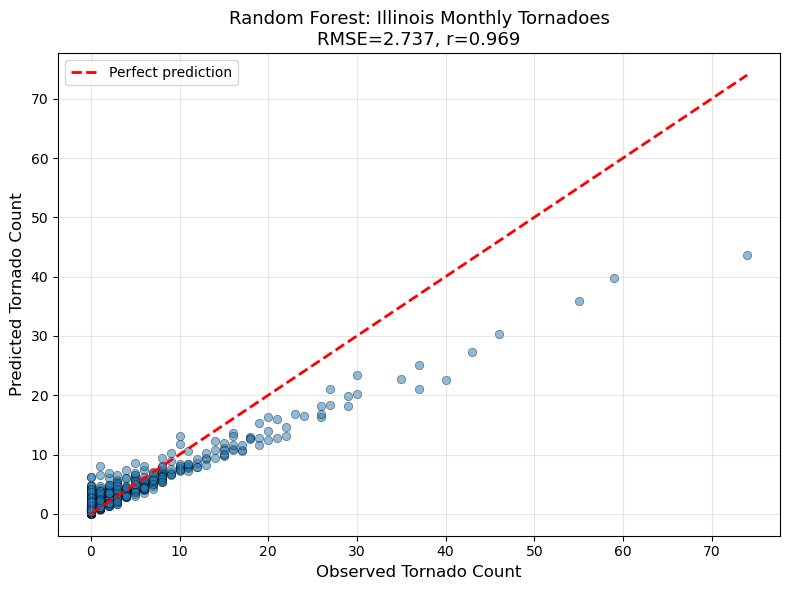

In [90]:
# Prepare data
illinois_climate_data = merged.dropna()

# Features
X = illinois_climate_data[['PDO', 'NAO', 'AO']]

# Target: tornado counts
y = illinois_climate_data['tornado_count']

# Create and train Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

# Make predictions
y_pred = rf_model.predict(X)

# Calculate metrics
rmse = root_mean_squared_error(y, y_pred)
corr, p_value = pearsonr(y, y_pred)

# Report results
print(f"RMSE: {rmse:.3f}")
print(f"Correlation coefficient (r): {corr:.3f}")

# Create scatter plot of predicted vs observed
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Observed Tornado Count', fontsize=12)
plt.ylabel('Predicted Tornado Count', fontsize=12)
plt.title(f'Random Forest: Illinois Monthly Tornadoes\nRMSE={rmse:.3f}, r={corr:.3f}', 
          fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

4\. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.



Q3 (climate only):    RMSE = 2.737, r = 0.969
Q4 (climate + month): RMSE = 2.602, r = 0.954
Comparison:           ΔRMSE = 0.136, Δr = -0.014


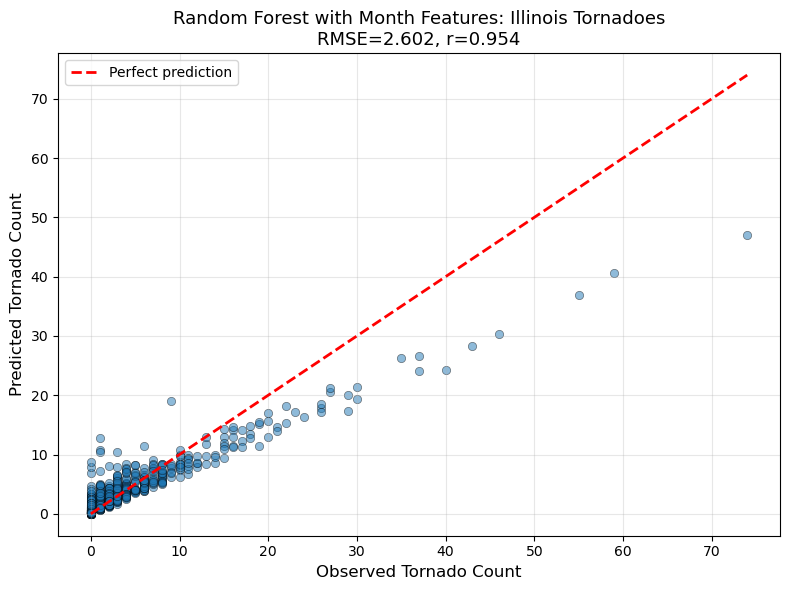

In [108]:
# Prepare clean data
data_clean = merged.dropna().copy()

# Extract month from the date index
months = data_clean.index.month.values.reshape(-1, 1)

# One-hot encode months
encoder = OneHotEncoder(sparse_output=False, drop=None)
month_encoded = encoder.fit_transform(months)

# Create month name mapping
month_map = {1: 'January', 2: 'February', 3: 'March', 4: 'April',
             5: 'May', 6: 'June', 7: 'July', 8: 'August',
             9: 'September', 10: 'October', 11: 'November', 12: 'December'}

# Map encoder categories to month names
month_names = [month_map[int(category)] for category in encoder.categories_[0]]

# Combine climate indices with month features
X_with_month = pd.concat([
    data_clean[['PDO', 'NAO', 'AO']],
    pd.DataFrame(month_encoded, columns=month_names, index=data_clean.index)
], axis=1)

# Target
y_with_month = data_clean['tornado_count'].values

# Train Random Forest with month features
rf_model_month = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model_month.fit(X_with_month, y_with_month)

# Make predictions
y_pred_month = rf_model_month.predict(X_with_month)

# Calculate metrics
rmse_month = root_mean_squared_error(y_with_month, y_pred_month)
corr_month, p_value_month = pearsonr(y_with_month, y_pred_month)

# Report results and comparison
print(f"Q3 (climate only):    RMSE = {rmse:.3f}, r = {corr:.3f}")
print(f"Q4 (climate + month): RMSE = {rmse_month:.3f}, r = {corr_month:.3f}")
print(f"Comparison:           ΔRMSE = {rmse - rmse_month:.3f}, Δr = {corr_month - corr:.3f}")

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_with_month, y_pred_month, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_with_month.min(), y_with_month.max()], 
         [y_with_month.min(), y_with_month.max()], 
         'r--', lw=2,
         label='Perfect prediction')
plt.xlabel('Observed Tornado Count', fontsize=12)
plt.ylabel('Predicted Tornado Count', fontsize=12)
plt.title(
    f'Random Forest with Month Features: Illinois Tornadoes\nRMSE={rmse_month:.3f}, r={corr_month:.3f}', 
    fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


5\. Perform a feature importance and multipass permutation analysis of your features.


6\. Create a SHAP Summary Plot showing feature importance and feature effects.

7\. Create a SHAP Feature Dependence for the ENSO index.

8\. Any observations on the importance of the various features in your model from the XAI techniques you tried?